# Amit Barilant, Alon Finestein

## Mount Goole Drive (only when use google drive)

In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')


# Define the directory path
# directory = '/content/drive/MyDrive/Project/semantic segmentation' #Amit
directory = '/content/drive/MyDrive/Deep Learning and its applications to Signal and Image Processing and Analysis/Project' # Alon

# Change the working directory to the specified folder
os.chdir(directory)


Mounted at /content/drive


# BYOL Training

## Imports

In [2]:
import os
from BYOL import *
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


In [ ]:
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## BYOL Training Function

In [4]:
def train_BYOL_save_weights(images_dir,batch_size=8, num_epochs=10, min_loss_delta=5e-4,weights_path=None):
    # Define the transformations
    transform = transforms.Compose([
          transforms.Resize((512, 512)),
          transforms.ToTensor(),
      ])

    # Create the dataset
    datasetBYOL = CustomImageDatasetBYOL(root_dir=images_dir, transform=transform)

    # Create the data loader
    dataLoaderBYOL = DataLoader(datasetBYOL, batch_size=batch_size, shuffle=True, num_workers=4)

    # Check if CUDA is available and set the device accordingly
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Define the BYOL model with U-Net encoder
    byol = BYOL(UNetEncoder).to(device)

    # Define the optimizer
    optimizer = optim.Adam(byol.parameters(), lr=1e-4)

    # Define the data augmentation transformations
    augment = transforms.Compose([

        # Apply RandomResizedCrop with a probability of 90%
        transforms.RandomApply(
            [transforms.RandomResizedCrop(size=(512, 512), scale=(0.08, 1.0))],
            p=0.9
        ),
        # Apply horizontal flip with a probability of 50%
        transforms.RandomHorizontalFlip(p=0.5),

        # Rotate the image by up to 10 degrees
        transforms.RandomRotation(10),

        # Apply ColorJitter with a probability of 30%
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.8, contrast=0.8)],
            p=0.3
        ),

    ])

    # Training loop
    num_epochs = num_epochs
    min_loss_delta = min_loss_delta
    losses = []  # To store the loss values

    for epoch in range(num_epochs):
        byol.train()
        running_loss = 0.0
        for images in dataLoaderBYOL:
            images = images.to(device)

            # Create image pairs by randomly augmenting the images
            x1 = torch.stack([augment(image.cpu()) for image in images]).to(device)
            x2 = torch.stack([augment(image.cpu()) for image in images]).to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            loss = byol(x1, x2)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update the target network
            byol.update_target_network()

            running_loss += loss.item()

        epoch_loss = running_loss / len(dataLoaderBYOL)
        losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

        # Check if the difference between successive losses is smaller than the threshold
        if epoch > 0 and abs(losses[-2] - epoch_loss) < min_loss_delta:
            print(f"Stopping early as the loss change is smaller than {min_loss_delta:.4f}")
            break

    # Plot the loss values after training
    plt.plot(losses, marker='o')
    plt.title('BYOL Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

    def save_online_encoder_weights(model, path):
        # Extract the state dict of the online encoder from the BYOL model
        full_state_dict = model.state_dict()
        filtered_state_dict = {}

        # Filter and rename the keys
        for key, value in full_state_dict.items():
            if key.startswith("online_encoder."):
                new_key = key[len("online_encoder."):]
                filtered_state_dict[new_key] = value

        # Save the filtered state dict
        torch.save(filtered_state_dict, path)

    if weights_path is not None:
        save_online_encoder_weights(byol, path=weights_path)

### Visualising the Augmentations (Optional)

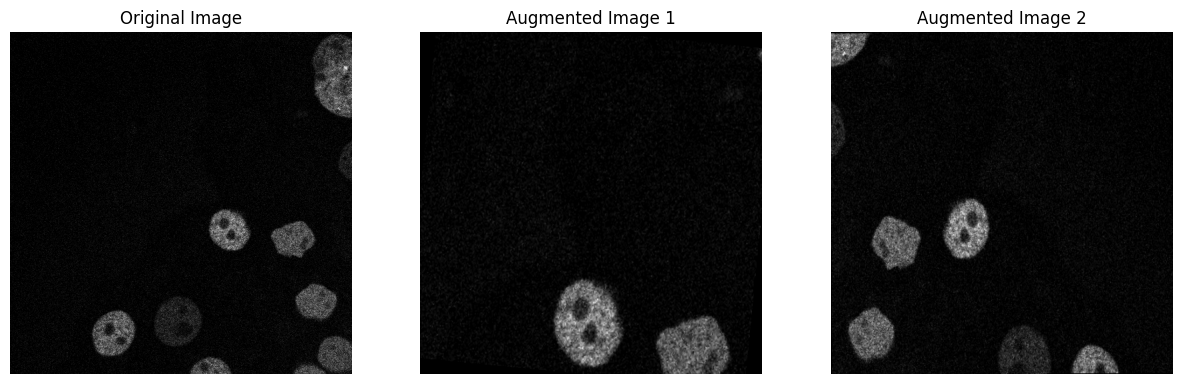

In [5]:
def visualize_augmentations(image_path, idx=0, samples=10, cols=5):
    # Define the data augmentation transformations
    augment = transforms.Compose([

        # Apply RandomResizedCrop with a probability of 90%
        transforms.RandomApply(
            [transforms.RandomResizedCrop(size=(512, 512), scale=(0.08, 1.0))],
            p=0.9
        ),
        # Apply horizontal flip with a probability of 50%
        transforms.RandomHorizontalFlip(p=0.5),

        # Rotate the image by up to 10 degrees
        transforms.RandomRotation(10),

        # Apply ColorJitter with a probability of 30%
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.8, contrast=0.8)],
            p=0.3
        ),

    ])

    # Load a sample image
    image = Image.open(image_path).convert('L')  # Convert to grayscale if needed

    # Apply the augmentations twice to create two augmented versions
    augmented_image_1 = augment(transforms.ToTensor()(image))
    augmented_image_2 = augment(transforms.ToTensor()(image))

    # Convert tensors back to PIL images for display
    augmented_image_1 = transforms.ToPILImage()(augmented_image_1)
    augmented_image_2 = transforms.ToPILImage()(augmented_image_2)

    # Plot the original and augmented images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(augmented_image_1, cmap='gray')
    axes[1].set_title('Augmented Image 1')
    axes[1].axis('off')

    axes[2].imshow(augmented_image_2, cmap='gray')
    axes[2].set_title('Augmented Image 2')
    axes[2].axis('off')

    plt.show()

visualize_augmentations('Fluo-N2DH-GOWT1 easy/BYOL data(no label) 736/t000_patch_0_0.png')

## Creating the UNet Encoder Weights

Epoch [1/10], Loss: 0.0486
Epoch [2/10], Loss: 0.0077
Epoch [3/10], Loss: 0.0036
Epoch [4/10], Loss: 0.0023
Epoch [5/10], Loss: 0.0018
Epoch [6/10], Loss: 0.0013
Stopping early as the loss change is smaller than 0.0005


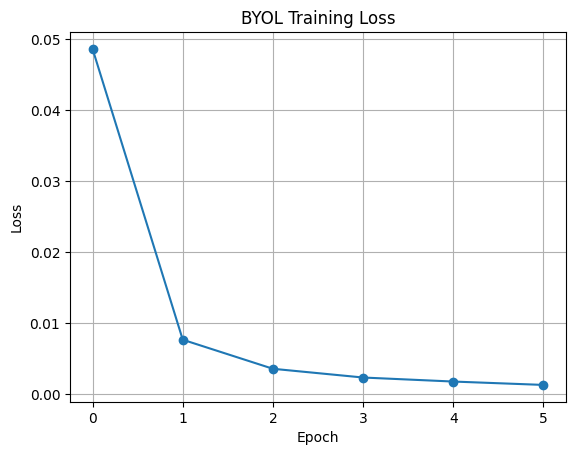

Epoch [1/10], Loss: 0.0454
Epoch [2/10], Loss: 0.0079
Epoch [3/10], Loss: 0.0045
Epoch [4/10], Loss: 0.0033
Epoch [5/10], Loss: 0.0021
Epoch [6/10], Loss: 0.0021
Stopping early as the loss change is smaller than 0.0005


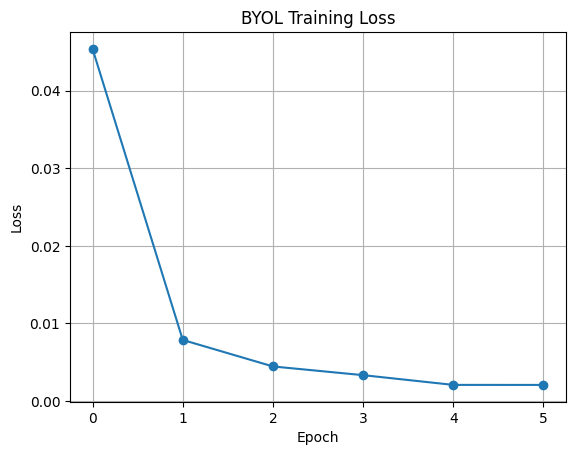

In [6]:
simple_data_path = 'Fluo-N2DH-GOWT1 easy/BYOL data(no label) 736'
train_BYOL_save_weights(simple_data_path,weights_path='Wighted_on_easy_512__semanticUnetEncoderByolWeights.pt')
complex_data_path = 'PhC-C2DL-PSC hard/BYOL data(no label) 600'
train_BYOL_save_weights(complex_data_path,weights_path='Wighted_on_hard_512__semanticUnetEncoderByolWeights.pt')

# UNet Training

## Improts

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributed as dist
from torchvision import transforms as T
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import models, datasets, transforms
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from scipy.ndimage import label
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import os
from scipy.ndimage import label, generic_filter
from scipy.ndimage import label, convolve

from UNet import *

## UNet Training Function

In [9]:
def UNet_trainig(image_dir, mask_dir, batch_size =8,num_epochs=1,encoder_weights_path=None,loss_weights = [0.15, 0.35, 0.4],learning_rate = 1e-4,output_weights_path= None):

    # Check if CUDA is available and set the device accordingly
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Initialize the model
    model = UNet(in_channels=1, out_channels=3).to(device)

    # Initialize weights function
    def init_weights(m):
        if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

    # Define transformations
    transform = T.Compose([
        T.Resize((512, 512)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ])

    # Create the dataset
    dataset = CellImageDatasetUNet(
        image_dir=image_dir,
        mask_dir= mask_dir,
        transform=transform
    )

    # Split dataset into training and validation (80% training, 20% validation)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    if encoder_weights_path is not None:
      # Load the weights to the CPU first
      encoder_weights = torch.load(encoder_weights_path, map_location=torch.device('cpu'))
      model.encoder.load_state_dict(encoder_weights)
      for param in model.encoder.parameters():
                    param.requires_grad = False
      print("Encoder weights loaded successfully.")
    else:
      model.encoder.apply(init_weights)
      for param in model.encoder.parameters():
                    param.requires_grad = True
                    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    # Initialize weights of the decoder
    model.decoder.apply(init_weights)
    # model.encoder.apply(init_weights)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Define the class weights
    class_weights = torch.tensor(loss_weights, device=device)

    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights)  # Use weighted CrossEntropyLoss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Track losses
    train_losses = []
    val_losses = []

    # Training loop
    num_epochs = num_epochs
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
          images = images.to(device)
          labels = labels.to(device).long().squeeze(1)  # Remove the channel dimension if present

          # Forward pass
          outputs = model(images)

          # Check shapes before calculating loss
          # print("Output shape:", outputs.shape)
          # print("Labels shape:", labels.shape)

          loss = criterion(outputs, labels)

          # Backward pass and optimization
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.4f}')

        # Validate the model
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).long()  # Ensure labels are long type for CrossEntropyLoss

                # Forward pass
                outputs = model(images)
                val_loss = criterion(outputs, labels)

                val_running_loss += val_loss.item()

        val_loss = val_running_loss / len(val_loader)
        val_losses.append(val_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {val_loss:.4f}')

        if encoder_weights_path is not None:
            if epoch == round(2*num_epochs/3):
                print("Unfreezing encoder weights.")
                for param in model.encoder.parameters():
                    param.requires_grad = True
                optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Update optimizer to include encoder parameters

    # Save the trained model weights
    if output_weights_path is not None:
        torch.save(model.state_dict(), f'{output_weights_path}')
        print(f"Model weights saved to {output_weights_path}")

    # Plot the training and validation losses
    print("Training complete!")

    # Plot training and validation losses
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.grid(True)
    plt.show()



## Testing Function

In [10]:
import os
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import cv2

def post_process_output(output, target_classes):
    # Apply softmax to get probabilities across the channels
    # print(output.shape)
    softmax_output = torch.softmax(output, dim=1)  # Assuming output shape is (1, 3, 512, 512)

    # Get the index of the max logit value for each pixel
    predicted_classes = torch.argmax(output, dim=1)  # Shape: (1, 512, 512)
    # print(predicted_classes)

    # Ensure the target_classes tensor is on the same device as predicted_classes
    target_classes_tensor = torch.tensor(target_classes, device=predicted_classes.device)

    # Create a binary mask where the target class is 1 if in channels 1 or 2, else 0
    binary_mask = torch.isin(predicted_classes, target_classes_tensor).cpu().numpy().astype(np.uint8).squeeze()

    # Optional: Convert binary mask to 255 for visualization purposes
    binary_mask_visual = binary_mask * 255

    return binary_mask_visual

# Function to load images and masks
def load_image_and_mask(image_path, mask_path):
    # Load the image
    image = Image.open(image_path).convert('L')
    mask = Image.open(mask_path).convert('L')

    # Resize and convert to tensor
    transform = T.Compose([
        T.Resize((512, 512)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ])

    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    mask_tensor = T.Resize((512, 512))(mask)

    return image_tensor, mask_tensor

# Function to calculate the Jaccard index
def calculate_jaccard_index(R, S):
    # Calculate intersection and union
    intersection = np.logical_and(R, S).sum()
    union = np.logical_or(R, S).sum()

    if union == 0:
        return 0

    return intersection / union

# Function to calculate the SEG measure using connected components on grayscale images
def calculate_seg_measure(reference_image, segmented_image):
    # Apply connected components directly on the grayscale images
    num_labels_R, labels_R = cv2.connectedComponents(reference_image, connectivity=8)
    num_labels_S, labels_S = cv2.connectedComponents(segmented_image, connectivity=8)

    jaccard_indices = []
    non_zero_jaccards = 0

    # Iterate through each reference object
    for label_R in range(1, num_labels_R):
        R_object = (labels_R == label_R).astype(np.uint8)

        best_jaccard = 0
        for label_S in range(1, num_labels_S):
            S_object = (labels_S == label_S).astype(np.uint8)

            # Check if this segmented object matches the reference object
            if np.logical_and(R_object, S_object).sum() > 0.5 * R_object.sum():
                jaccard = calculate_jaccard_index(R_object, S_object)
                best_jaccard = max(best_jaccard, jaccard)
                break

        if best_jaccard > 0:
            non_zero_jaccards += 1

        jaccard_indices.append(best_jaccard)

    # Calculate the SEG measure as the mean of the Jaccard indices
    if len(jaccard_indices) == 0:
        return 1, 0, 0

    seg_mean = np.mean(jaccard_indices)
    total_components = len(jaccard_indices)

    return seg_mean, non_zero_jaccards, total_components

# Function to display results
def display_results(original_image, ground_truth_mask, predicted_mask):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Display Original Image
    axs[0].imshow(original_image.squeeze(), cmap='gray')
    axs[0].set_title("Original Image")
    axs[0].axis('off')

    # Display Ground Truth Mask
    axs[1].imshow(ground_truth_mask, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis('off')

    # Display Predicted Mask
    axs[2].imshow(predicted_mask.squeeze(), cmap='gray')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')

    plt.show()

# Function to process and display all images in the directory
def process_and_display_all_images(image_dir, mask_dir, model,black_edges = True, show_results=False,):

    # Check if CUDA is available and set the device accordingly
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Get a list of image and mask filenames
    image_filenames = os.listdir(image_dir)

    total_seg_scores = []
    total_non_zero_jaccards = 0
    total_components = 0

    for image_name in image_filenames:
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, image_name)
        # print(mask_path)

        if not os.path.exists(mask_path):
            print(f"Skipping {image_name} because the corresponding mask doesn't exist.")
            continue  # Skip if the corresponding mask doesn't exist

        # Load the image and mask
        image_tensor, ground_truth_mask = load_image_and_mask(image_path, mask_path)

        # Move image tensor to the correct device
        image_tensor = image_tensor.to(device)

        # Get the model output
        with torch.no_grad():
            output = model(image_tensor)

        # Post-process the output to generate the predicted mask
        if black_edges:
            target_classes = (1)
        else:
            target_classes = (1,2)
        predicted_mask = post_process_output(output,target_classes)
        predicted_mask = predicted_mask.squeeze() #convert to NumPy for further processing

        # Convert PIL Image mask to numpy array
        ground_truth_mask = np.array(ground_truth_mask)

        # Calculate the SEG measure
        seg_mean, non_zero_jaccards, components = calculate_seg_measure(ground_truth_mask, predicted_mask)


        # Store the results for calculating the overall mean
        total_seg_scores.append(seg_mean)
        total_non_zero_jaccards += non_zero_jaccards
        total_components += components

        # Display the results
        if show_results:
          print(f'Example Image: {image_name}')
          print(f'SEG measure for {image_name}: {seg_mean}')
          print(f'Non-zero Jaccard indices: {non_zero_jaccards}/{components}')
          display_results(image_tensor.cpu().numpy(), ground_truth_mask, predicted_mask)
          show_results = False #Show only the first image

    # Calculate the overall mean SEG score
    overall_mean_seg = np.mean(total_seg_scores) if total_seg_scores else 0
    print(f'\nOverall Mean SEG: {overall_mean_seg}')
    print(f'Total Non-zero Jaccard indices: {total_non_zero_jaccards}/{total_components}')




# Training and testing


## Choosing Images & Masks Paths

In [12]:
## Simple Dataset
# # 50 images
# image_dir = 'Fluo-N2DH-GOWT1 easy/dataset 50/train50 images'
# mask_dir = 'Fluo-N2DH-GOWT1 easy/dataset 50/train50 masks'

# # 100 images
# image_dir = 'Fluo-N2DH-GOWT1 easy/dataset 100/train100 images'
# mask_dir = 'Fluo-N2DH-GOWT1 easy/dataset 100/train100 masks'

# # 250 images
# image_dir = 'Fluo-N2DH-GOWT1 easy/dataset 250/train250 images'
# mask_dir = 'Fluo-N2DH-GOWT1 easy/dataset 250/train250 masks'

# # 500 images
# image_dir = 'Fluo-N2DH-GOWT1 easy/dataset 500/train500 images'
# mask_dir = 'Fluo-N2DH-GOWT1 easy/dataset 500/train500 masks'

# # test images
# test_image_dir = 'Fluo-N2DH-GOWT1 easy/test120/test120 images'
# test_mask_dir = 'Fluo-N2DH-GOWT1 easy/test120/test120 masks'

# # weights paths
# same_weights_path = 'Wighted_on_easy_512__semanticUnetEncoderByolWeights.pt'
# diff_weights_path = 'Wighted_on_hard_512__semanticUnetEncoderByolWeights.pt'

## Complex Dataset
# # 50 images
# image_dir = 'PhC-C2DL-PSC hard/dataset 50/train50 images'
# mask_dir = 'PhC-C2DL-PSC hard/dataset 50/train50 masks'

# # 100 images
# image_dir = 'PhC-C2DL-PSC hard/dataset 100/train100 images'
# mask_dir = 'PhC-C2DL-PSC hard/dataset 100/train100 masks'

# # 250 images
# image_dir = 'PhC-C2DL-PSC hard/dataset 250/train250 images'
# mask_dir = 'PhC-C2DL-PSC hard/dataset 250/train250 masks'

# 500 images
image_dir = 'PhC-C2DL-PSC hard/dataset 500/train500 images'
mask_dir = 'PhC-C2DL-PSC hard/dataset 500/train500 masks'

# test images
test_image_dir = 'PhC-C2DL-PSC hard/test100/test100 images'
test_mask_dir = 'PhC-C2DL-PSC hard/test100/test100 masks'

# weights paths
same_weights_path = 'Wighted_on_hard_512__semanticUnetEncoderByolWeights.pt'
diff_weights_path = 'Wighted_on_easy_512__semanticUnetEncoderByolWeights.pt'

## Simple UNet

Epoch [1/10], Training Loss: 0.8422
Epoch [1/10], Validation Loss: 0.7383
Epoch [2/10], Training Loss: 0.7307
Epoch [2/10], Validation Loss: 0.7000
Epoch [3/10], Training Loss: 0.6605
Epoch [3/10], Validation Loss: 0.6222
Epoch [4/10], Training Loss: 0.6104
Epoch [4/10], Validation Loss: 0.6058
Epoch [5/10], Training Loss: 0.5954
Epoch [5/10], Validation Loss: 0.5927
Epoch [6/10], Training Loss: 0.5888
Epoch [6/10], Validation Loss: 0.5860
Epoch [7/10], Training Loss: 0.5840
Epoch [7/10], Validation Loss: 0.5814
Epoch [8/10], Training Loss: 0.5810
Epoch [8/10], Validation Loss: 0.5792
Epoch [9/10], Training Loss: 0.5786
Epoch [9/10], Validation Loss: 0.5800
Epoch [10/10], Training Loss: 0.5763
Epoch [10/10], Validation Loss: 0.5762
Model weights saved to trained_UNet_weights.pth
Training complete!


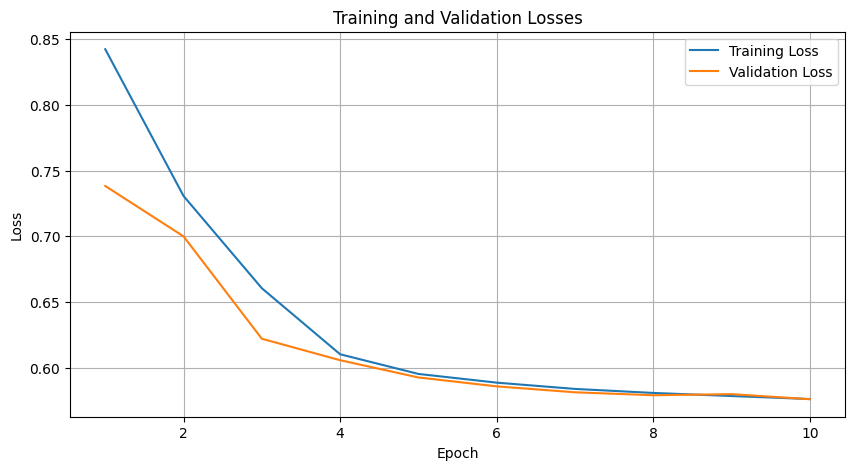

In [ ]:
UNet_trainig(image_dir,mask_dir,batch_size=8,num_epochs=10,output_weights_path='trained_UNet_weights.pth')


<ipython-input-13-9ecdc62e6900>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('trained_UNet_weights.pth'))


Example Image: t503.png
SEG measure for t503.png: 0.26932084823723446
Non-zero Jaccard indices: 56/117


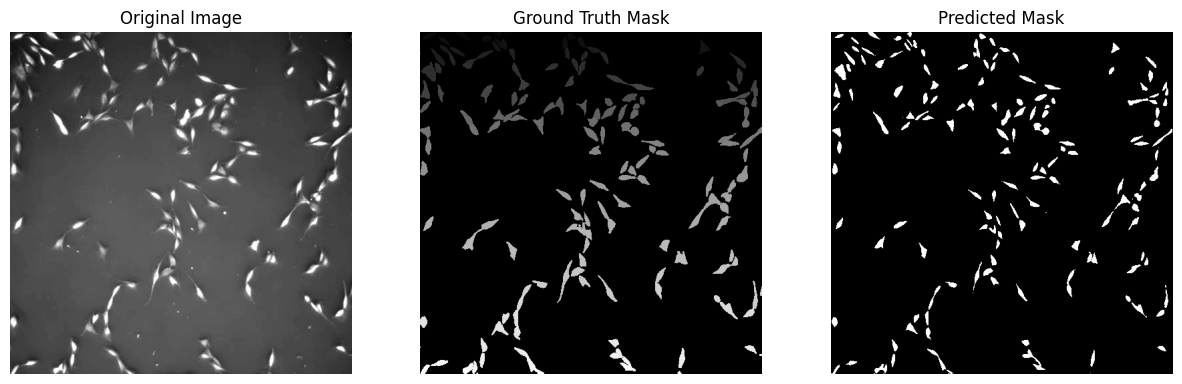


Overall Mean SEG: 0.2093618043886547
Total Non-zero Jaccard indices: 5628/15590


In [13]:
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved weights
model = UNet(in_channels=1, out_channels=3).to(device)
model.load_state_dict(torch.load('trained_UNet_weights.pth'))
model.eval()

# Then process the images
process_and_display_all_images(test_image_dir, test_mask_dir, model,black_edges=True, show_results=True)


## Unet & BYOL

Encoder weights loaded successfully.


<ipython-input-15-7c2f050c0758>:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_weights = torch.load(encoder_weights_path, map_location=torch.device('cpu'))
/usr/l

Epoch [1/3], Training Loss: 0.6393
Epoch [1/3], Validation Loss: 0.5906
Epoch [2/3], Training Loss: 0.5834
Epoch [2/3], Validation Loss: 0.5804
Epoch [3/3], Training Loss: 0.5764
Epoch [3/3], Validation Loss: 0.5772
Unfreezing encoder weights.
Model weights saved to trained_UNetandBYOL_weights.pth
Training complete!


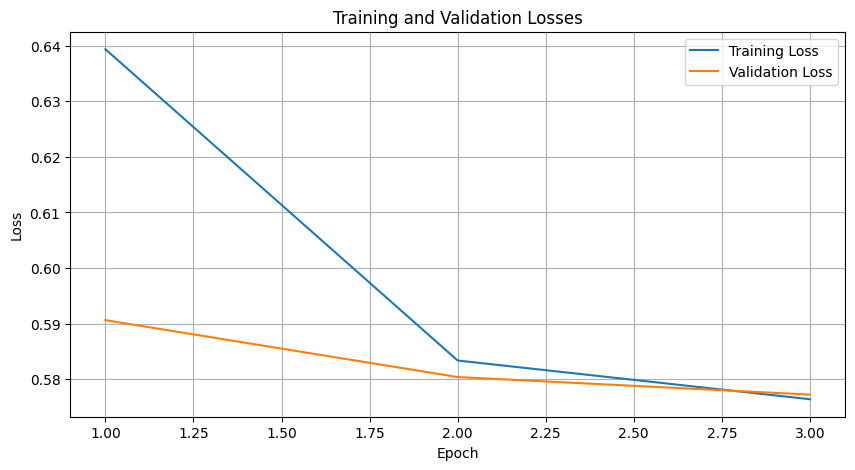

In [ ]:
UNet_trainig(image_dir,mask_dir,batch_size=8,num_epochs=3,encoder_weights_path= same_weights_path,output_weights_path='trained_UNetandBYOL_weights.pth')

<ipython-input-14-e982d9743f40>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('trained_UNetandBYOL_weights.pth'))


Example Image: t503.png
SEG measure for t503.png: 0.18280325233682043
Non-zero Jaccard indices: 38/117


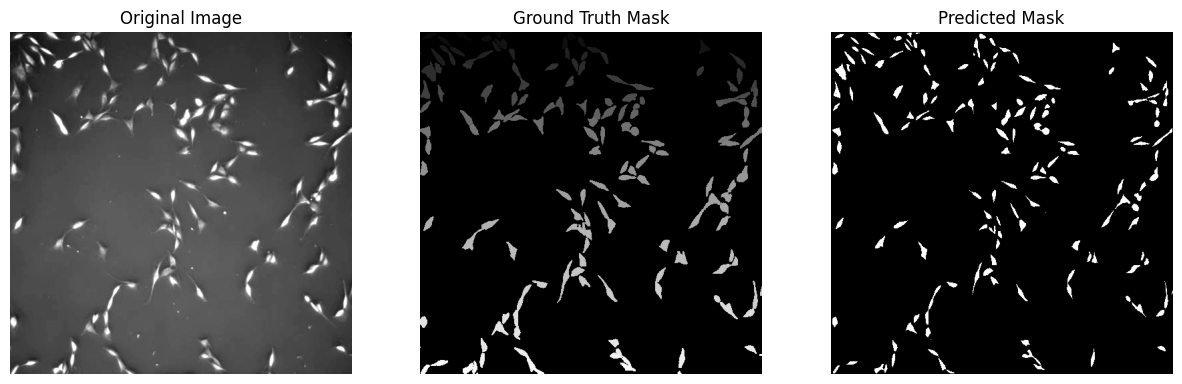


Overall Mean SEG: 0.1791000002491738
Total Non-zero Jaccard indices: 4934/15590


In [14]:
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved weights
model = UNet(in_channels=1, out_channels=3).to(device)
model.load_state_dict(torch.load('trained_UNetandBYOL_weights.pth'))
model.eval()

# Then process the images
process_and_display_all_images(test_image_dir, test_mask_dir, model,black_edges=True, show_results=True)

## UNet & Other BYOL

Encoder weights loaded successfully.


<ipython-input-15-7c2f050c0758>:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_weights = torch.load(encoder_weights_path, map_location=torch.device('cpu'))


Epoch [1/3], Training Loss: 0.6783
Epoch [1/3], Validation Loss: 0.5995
Epoch [2/3], Training Loss: 0.5892
Epoch [2/3], Validation Loss: 0.5861
Epoch [3/3], Training Loss: 0.5792
Epoch [3/3], Validation Loss: 0.5808
Unfreezing encoder weights.
Model weights saved to trained_UNetandOther_weights.pth
Training complete!


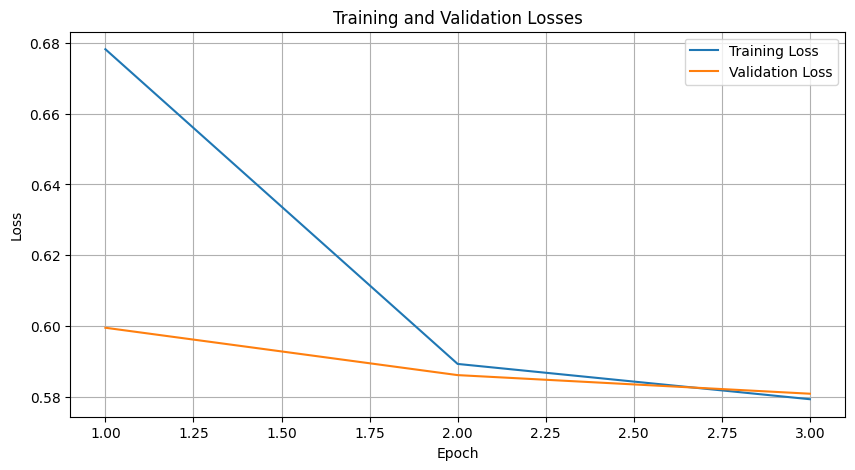

In [ ]:
UNet_trainig(image_dir,mask_dir,batch_size=8,num_epochs=10,encoder_weights_path= diff_weights_path,output_weights_path='trained_UNetandOther_weights.pth')

<ipython-input-15-4c12f75b1544>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('trained_UNetandOther_weights.pth'))


Example Image: t503.png
SEG measure for t503.png: 0.2327240979286455
Non-zero Jaccard indices: 49/117


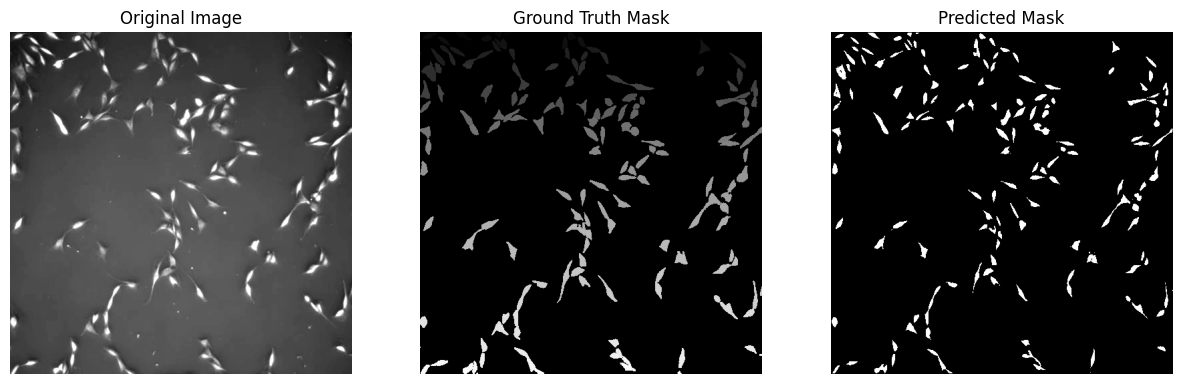


Overall Mean SEG: 0.19947273436914512
Total Non-zero Jaccard indices: 5479/15590


In [15]:
# Define the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the saved weights
model = UNet(in_channels=1, out_channels=3).to(device)
model.load_state_dict(torch.load('trained_UNetandOther_weights.pth'))
model.eval()

# Then process the images
process_and_display_all_images(test_image_dir, test_mask_dir, model,black_edges=True, show_results=True)